In [1]:
import xarray as xr
import glob
import shutil
import os
import re
import time
from dask.distributed import Client
from rechunker import rechunk
import zarr
import types

In [2]:
from dask.distributed import Client

client = Client(processes=True, threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 14
Total threads: 14,Total memory: 510.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46247,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39165,Total threads: 1
Dashboard: /proxy/33963/status,Memory: 36.43 GiB
Nanny: tcp://127.0.0.1:42719,


In [3]:
from datetime import datetime

now = datetime.now()
print(now.strftime("%H:%M:%S"))

11:25:39


In [4]:
#settings
SCRATCH_DIR = f"/scratch/m35/nm5072/OM2_025_MLT_MHW"
FINAL_ZARR = f"{SCRATCH_DIR}/OM2_025_1988-2018_rechunk_spat90.zarr"

# Temp locations (overwritten each loop)
TEMP_ZARR_TARGET = f"{SCRATCH_DIR}/temp_target.zarr"
TEMP_ZARR_INTERM = f"{SCRATCH_DIR}/temp_interm.zarr"
TARGET_CHUNKS = {'time': -1, 'yt_ocean': 90, 'xt_ocean': 90} 
MAX_MEM = "16GB"

In [5]:
# === Setup ===
base = '/scratch/e14/rmh561/access-om2/archive/025deg_jra55_iaf_cycle6_online_mlt/'
file_pattern = os.path.join(base, "output*/ocean/ocean_daily.nc")

# grab everything first
all_files = glob.glob(file_pattern)

# keep only output336–output366
file_list = []
for f in all_files:
    m = re.search(r'output(\d+)', f)
    if m:
        n = int(m.group(1))
        if 336 <= n <= 366:
            file_list.append(f)

file_list = sorted(file_list)

if not file_list:
    raise FileNotFoundError("No matching ocean_daily.nc files found in output336–output366!")

In [6]:
file_list

['/scratch/e14/rmh561/access-om2/archive/025deg_jra55_iaf_cycle6_online_mlt/output336/ocean/ocean_daily.nc',
 '/scratch/e14/rmh561/access-om2/archive/025deg_jra55_iaf_cycle6_online_mlt/output337/ocean/ocean_daily.nc',
 '/scratch/e14/rmh561/access-om2/archive/025deg_jra55_iaf_cycle6_online_mlt/output338/ocean/ocean_daily.nc',
 '/scratch/e14/rmh561/access-om2/archive/025deg_jra55_iaf_cycle6_online_mlt/output339/ocean/ocean_daily.nc',
 '/scratch/e14/rmh561/access-om2/archive/025deg_jra55_iaf_cycle6_online_mlt/output340/ocean/ocean_daily.nc',
 '/scratch/e14/rmh561/access-om2/archive/025deg_jra55_iaf_cycle6_online_mlt/output341/ocean/ocean_daily.nc',
 '/scratch/e14/rmh561/access-om2/archive/025deg_jra55_iaf_cycle6_online_mlt/output342/ocean/ocean_daily.nc',
 '/scratch/e14/rmh561/access-om2/archive/025deg_jra55_iaf_cycle6_online_mlt/output343/ocean/ocean_daily.nc',
 '/scratch/e14/rmh561/access-om2/archive/025deg_jra55_iaf_cycle6_online_mlt/output344/ocean/ocean_daily.nc',
 '/scratch/e14/rmh5

In [7]:
chunks_config = {time:-1}

# --- 3. Open Dataset Efficiently ---
# coords='minimal' and compat='override' stop xarray from reading 
# lat/lon from every single file, which speeds up opening significantly.
ds = xr.open_mfdataset(
    file_list, 
    parallel=True,
    coords='minimal', 
    compat='override', 
    # Add these three lines:
    combine='nested',
    concat_dim='time',
    decode_times=True, 
    data_vars=['temp_in_mld']
)

# Subset data to region and time
temp_mld = ds["temp_in_mld"].sel(
    time=slice("1989-01-01", "2018-12-31")
)

# Convert to degrees Celsius and rename
temp = (temp_mld / 1035).rename("temp")

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/dask/_task_spec.py:763: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  return self.func(*new_argspec, **kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/dask/_task_spec.py:763: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instea

In [8]:
temp

<xarray.DataArray 'temp' (time: 10957, yt_ocean: 1080, xt_ocean: 1440)> Size: 68GB
dask.array<truediv, shape=(10957, 1080, 1440), dtype=float32, chunksize=(1, 216, 240), chunktype=numpy.ndarray>
Coordinates:
  * xt_ocean  (xt_ocean) float64 12kB -279.9 -279.6 -279.4 ... 79.38 79.62 79.88
  * yt_ocean  (yt_ocean) float64 9kB -81.08 -80.97 -80.87 ... 89.74 89.84 89.95
  * time      (time) datetime64[ns] 88kB 1989-01-01T12:00:00 ... 2018-12-31T1...

In [9]:
# # Wrap in dataset and chunk
ds = temp.to_dataset()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 19.59 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


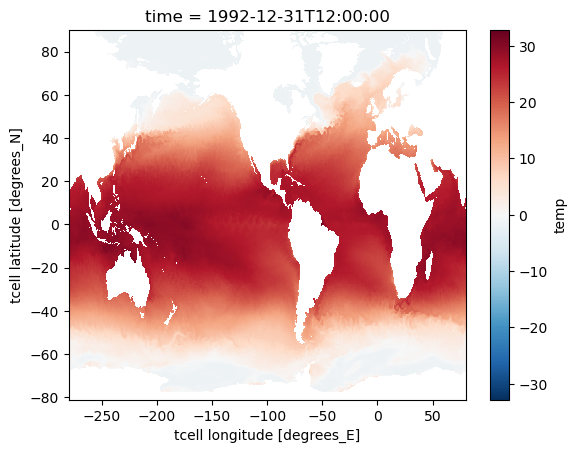

In [10]:
ds.temp.sel(time='1992-12-31').plot()

In [12]:
# 2. Clean Temp
for p in [FINAL_ZARR, TEMP_ZARR_INTERM, TEMP_ZARR_TARGET]:
    if os.path.exists(p): shutil.rmtree(p)
ds32 = ds[['temp']]#.astype('float32')
# Make source chunks Zarr-compatible and simple
ds32 = ds32.chunk({'time': 365, 'yt_ocean': -1, 'xt_ocean': -1})
# time=-1 becomes 365 or 366 (Length of this specific year)
plan = rechunk(
    ds32,         # optionally just 'sst'
    TARGET_CHUNKS,
    MAX_MEM,
    FINAL_ZARR,          # <- write final store here
    temp_store=TEMP_ZARR_INTERM,
)
plan.execute()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 30.99 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<zarr.hierarchy.Group '/'>

In [13]:
now = datetime.now()
print(now.strftime("%H:%M:%S"))

11:45:47


In [24]:
ds = xr.open_zarr(FINAL_ZARR)

/jobfs/159626648.gadi-pbs/ipykernel_1509960/1743875780.py:1: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ds = xr.open_zarr(FINAL_ZARR)


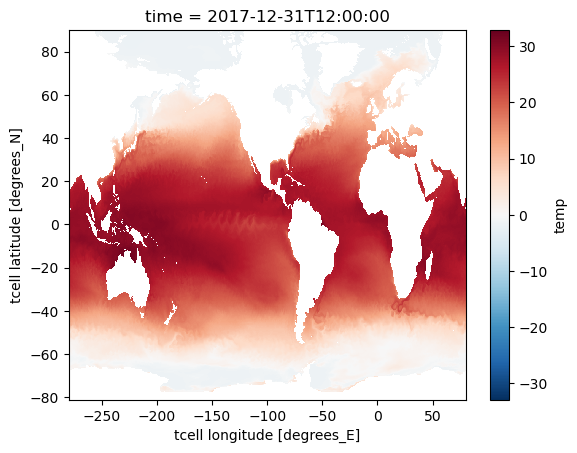

In [25]:
ds.temp.sel(time='2017-12-31').plot()

In [26]:
import sys
sys.path.append('/home/561/nm5072/MHW_sandbox')
import bipolarMhwToolBox as MHW
# === Calculate climatology ===
Seas = MHW.smoothedClima_mhw(ds)
Seas.to_netcdf("/scratch/m35/nm5072/OM2_025_MLT_MHW/om2_025_MLT_clim.nc")

In [17]:
now = datetime.now()
print(now.strftime("%H:%M:%S"))

11:57:08


In [18]:
# === Calculate threshold ===
Thresh = MHW.smoothedThresh_mhw(ds)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/dask/array/core.py:4998: PerformanceWarning: Increasing number of chunks by factor of 16
  result = blockwise(


In [19]:
Thresh = Thresh.compute()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1545: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1545: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1545: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1545: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1545: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/g/data/xp65/public/apps/med_conda/envs/

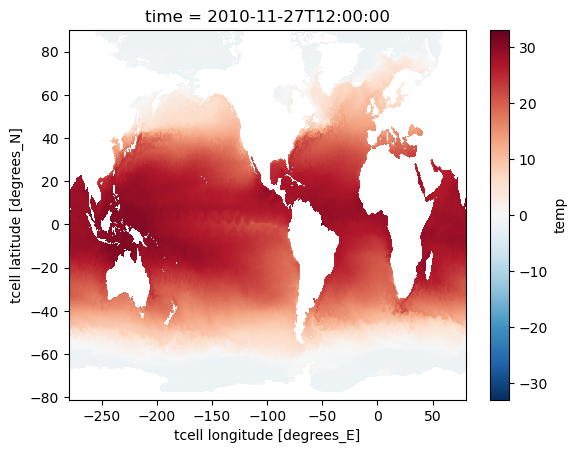

In [20]:
ds.temp.isel(time=8000).plot()

In [21]:
Thresh.to_netcdf("/scratch/m35/nm5072/OM2_025_MLT_MHW/om2_025_MLT_thresh.nc")

In [22]:
now = datetime.now()
print(now.strftime("%H:%M:%S"))

13:07:20


In [27]:
clim = xr.open_dataset("/scratch/m35/nm5072/OM2_025_MLT_MHW/om2_025_MLT_clim.nc")
threshhold = xr.open_dataset("/scratch/m35/nm5072/OM2_025_MLT_MHW/om2_025_MLT_thresh.nc")

In [28]:
threshhold

<xarray.Dataset> Size: 2GB
Dimensions:    (xt_ocean: 1440, yt_ocean: 1080, dayofyear: 366)
Coordinates:
  * xt_ocean   (xt_ocean) float64 12kB -279.9 -279.6 -279.4 ... 79.62 79.88
  * yt_ocean   (yt_ocean) float64 9kB -81.08 -80.97 -80.87 ... 89.74 89.84 89.95
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
Data variables:
    temp       (yt_ocean, xt_ocean, dayofyear) float32 2GB ...

In [49]:
150-360

-210

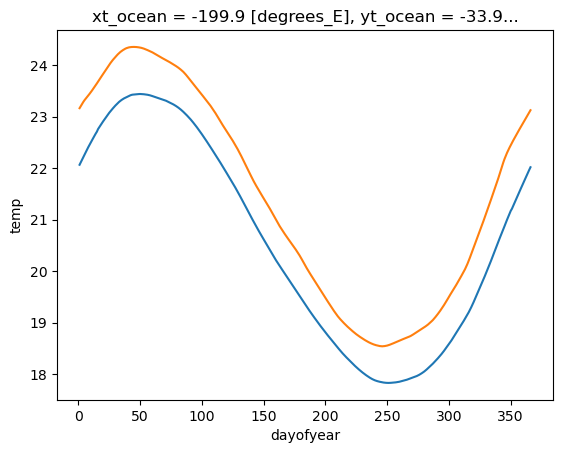

In [54]:
clim.temp.sel(yt_ocean=-34,xt_ocean=-200, method='nearest').plot()
threshhold.temp.sel(yt_ocean=-34,xt_ocean=-200, method='nearest').plot()

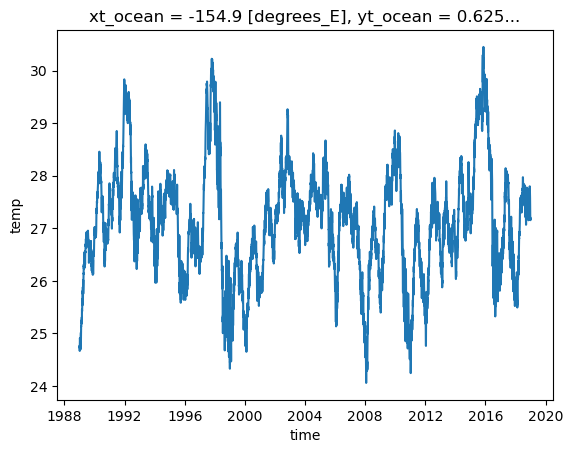

In [35]:
ds.temp.isel(yt_ocean=500,xt_ocean=500).plot()

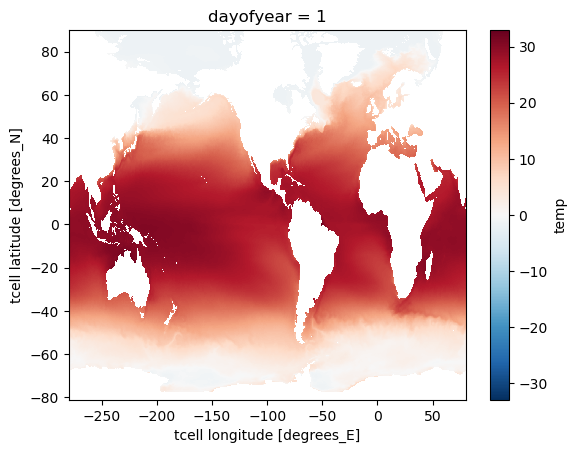

In [53]:
threshhold.temp.isel(dayofyear=0).plot()